In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3
import os

# set styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# folder to save the charts
CHARTS_DIR = "../reports/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

# connecting to sql to get the data
DB_PATH = "../db/bluestock_mf.db"
conn = sqlite3.connect(DB_PATH)

# csv path for the proccessed data that are not yet in the database
PROCESSED_DIR = "../data/processed"

print("database connected successfully")

database connected successfully


In [12]:
# Task 1 - NAV trend analysis (2022–2026), highlighting Post-COVID, 2023 Rally, and 2024 Correction periods
nav_query = """
SELECT n.date, n.nav, f.scheme_name 
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
WHERE n.date >= '2022-01-01'
"""
df_nav = pd.read_sql_query(nav_query, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Plot using Plotly for interactive trendlines
fig1 = px.line(df_nav, x='date', y='nav', color='scheme_name', 
              title='Daily NAV Trend for Schemes (2022-2026)')

# Highlight key market events with staggered annotation positions to prevent overlap
fig1.add_vrect(x0="2022-01-01", x1="2022-06-30", fillcolor="orange", opacity=0.1, 
               annotation_text="Post-COVID", annotation_position="top left")

fig1.add_vrect(x0="2023-03-01", x1="2023-12-31", fillcolor="green", opacity=0.1, 
               annotation_text="2023 Rally", annotation_position="bottom right")

fig1.add_vrect(x0="2024-05-01", x1="2024-08-01", fillcolor="red", opacity=0.1, 
               annotation_text="2024 Correction", annotation_position="top right")

fig1.write_image(f"{CHARTS_DIR}/01_NAV_Trend.png")
fig1.show()

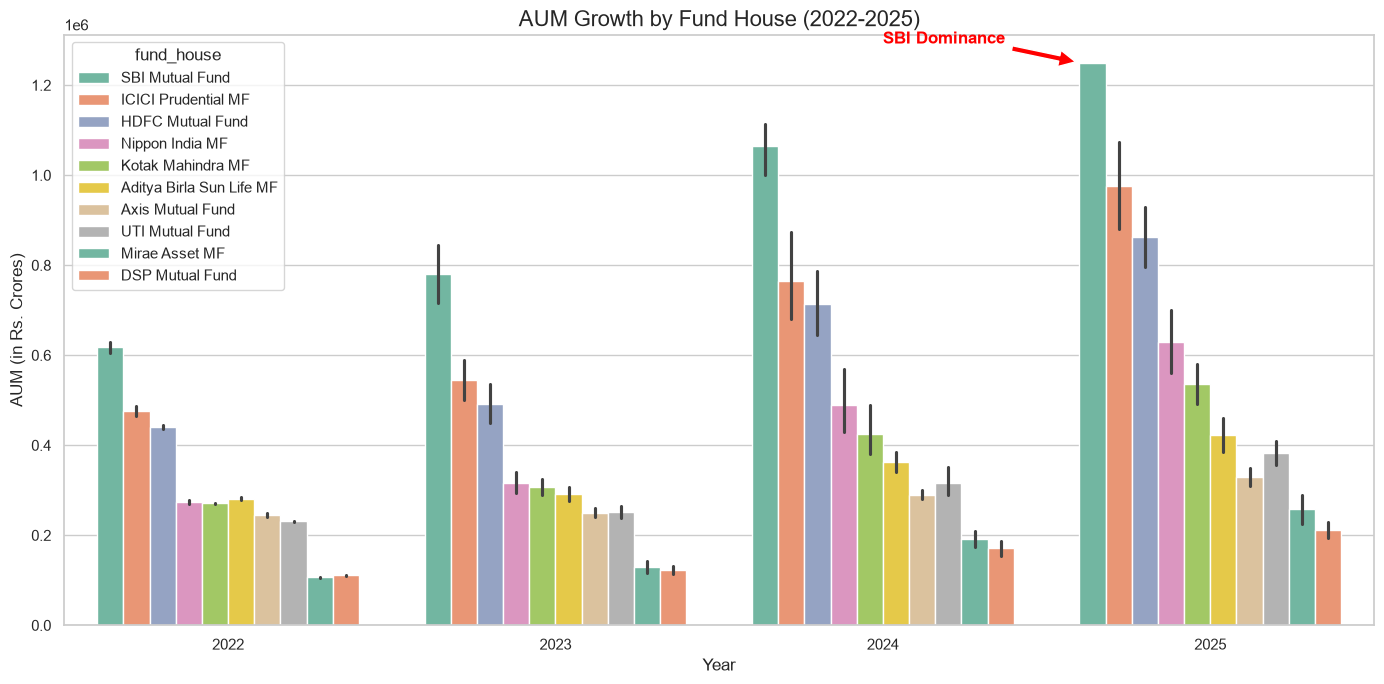

In [31]:
# Task 2 - Grouped bar chart for AUM Growth, highlighting SBI's dominance in 2025
df_aum = pd.read_csv(f"{PROCESSED_DIR}/clean_aum_by_fund_house.csv")

# Extract the year from your 'date' column
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum['year'] = df_aum['date'].dt.year

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_aum, x='year', y='aum_crore', hue='fund_house', palette="Set2")

plt.title('AUM Growth by Fund House (2022-2025)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('AUM (in Rs. Crores)', fontsize=12)

# Find the max AUM dynamically so the annotation arrow points to the right place
max_aum = df_aum['aum_crore'].max()

# Highlight SBI's dominance
plt.annotate('SBI Dominance', xy=(2.6, max_aum), xytext=(2, max_aum * 1.05 - 2e4),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=12, color='red', weight='bold')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_AUM_Growth.png", dpi=300)
plt.show()

In [34]:
# Cell 4: Task 3 - Monthly SIP Inflow (Jan 2022 to Dec 2025)
df_sip = pd.read_csv(f"{PROCESSED_DIR}/clean_monthly_sip_inflows.csv")

# Ensure month is parsed as a datetime object for the x-axis
df_sip['month'] = pd.to_datetime(df_sip['month'])

# Plot using the exact column name 'sip_inflow_crore'
fig3 = px.line(df_sip, x='month', y='sip_inflow_crore', markers=True,
               title='Monthly SIP Inflows (Jan 2022 - Dec 2025)')

# Mark the specific milestone from the rubric
fig3.add_annotation(x="2025-12-01", y=31002,
            text="Milestone: Rs. 31,002 Cr", showarrow=True, arrowhead=2, arrowcolor="green")

# Save and display
fig3.write_image(f"{CHARTS_DIR}/03_SIP_Inflow_Trend.png")
fig3.show()

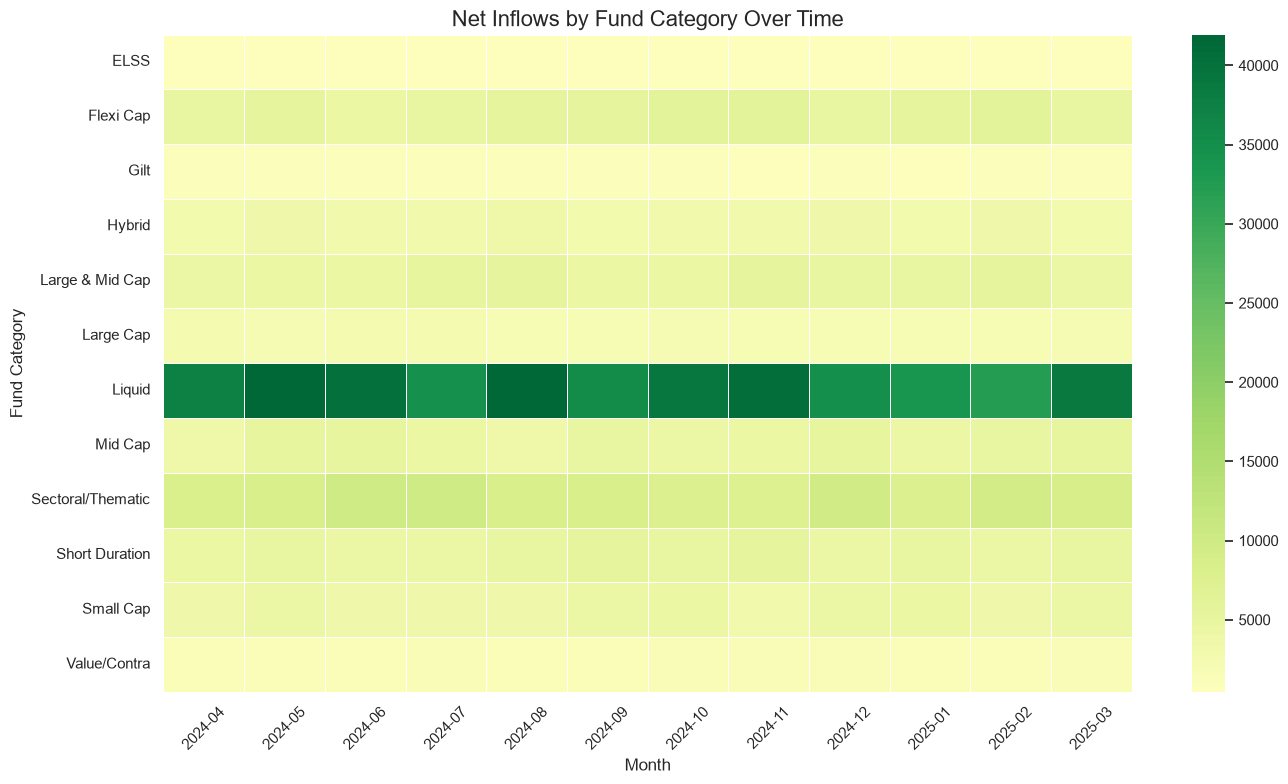

In [36]:
# Task 4 - Category-wise Inflow Heatmap
df_cat_inflow = pd.read_csv(f"{PROCESSED_DIR}/clean_category_inflows.csv")

# Create a pivot table to format data for the heatmap
pivot_cat = df_cat_inflow.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_cat, cmap="RdYlGn", center=0, annot=False, linewidths=.5)
plt.title('Net Inflows by Fund Category Over Time', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_Category_Heatmap.png", dpi=300)
plt.show()

C:\Users\aarav\AppData\Local\Temp\ipykernel_20272\2341178825.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=sip_data, x='age_group', y='amount_inr', palette="Set3")


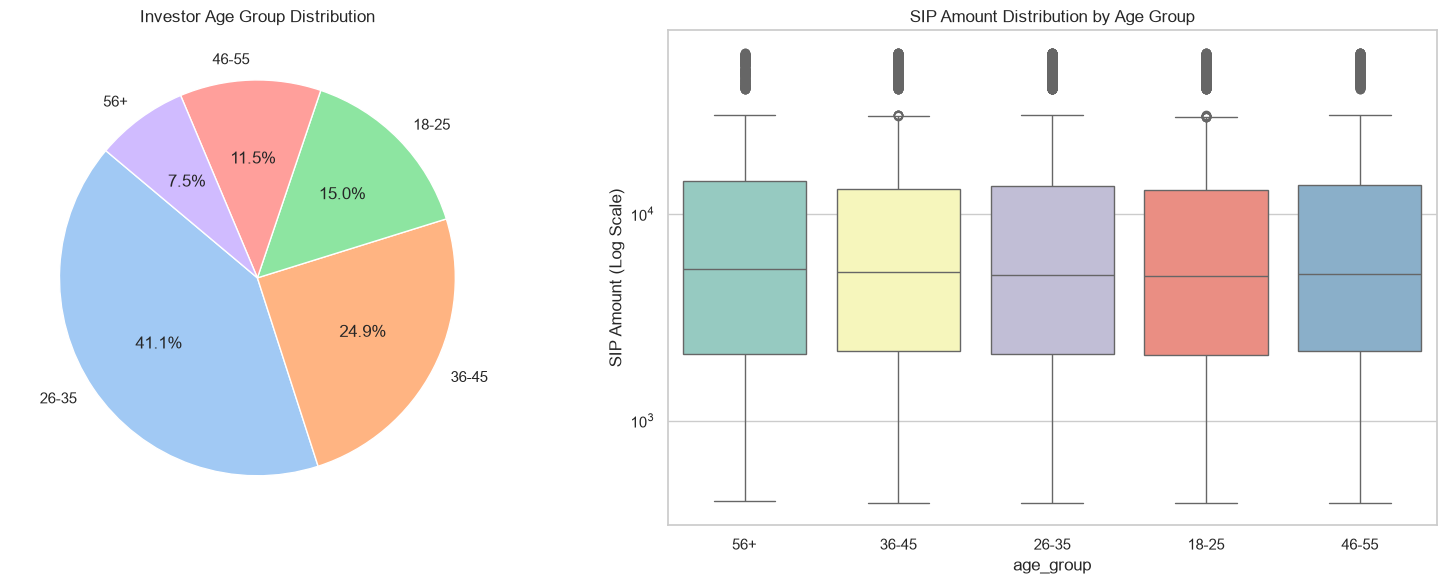

In [37]:
# Task 5 - Demographics: Pie Chart & Box Plot
trans_query = "SELECT age_group, transaction_type, amount_inr FROM fact_transactions"
df_demo = pd.read_sql_query(trans_query, conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie Chart
age_counts = df_demo['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
axes[0].set_title('Investor Age Group Distribution')

# Box Plot
sip_data = df_demo[df_demo['transaction_type'] == 'Sip']
sns.boxplot(ax=axes[1], data=sip_data, x='age_group', y='amount_inr', palette="Set3")
axes[1].set_title('SIP Amount Distribution by Age Group')
axes[1].set_yscale('log') # Log scale is essential for financial box plots due to large outliers
axes[1].set_ylabel('SIP Amount (Log Scale)')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05_Demographics.png", dpi=300)
plt.show()

C:\Users\aarav\AppData\Local\Temp\ipykernel_20272\82480539.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=state_sip.values, y=state_sip.index, palette="viridis")


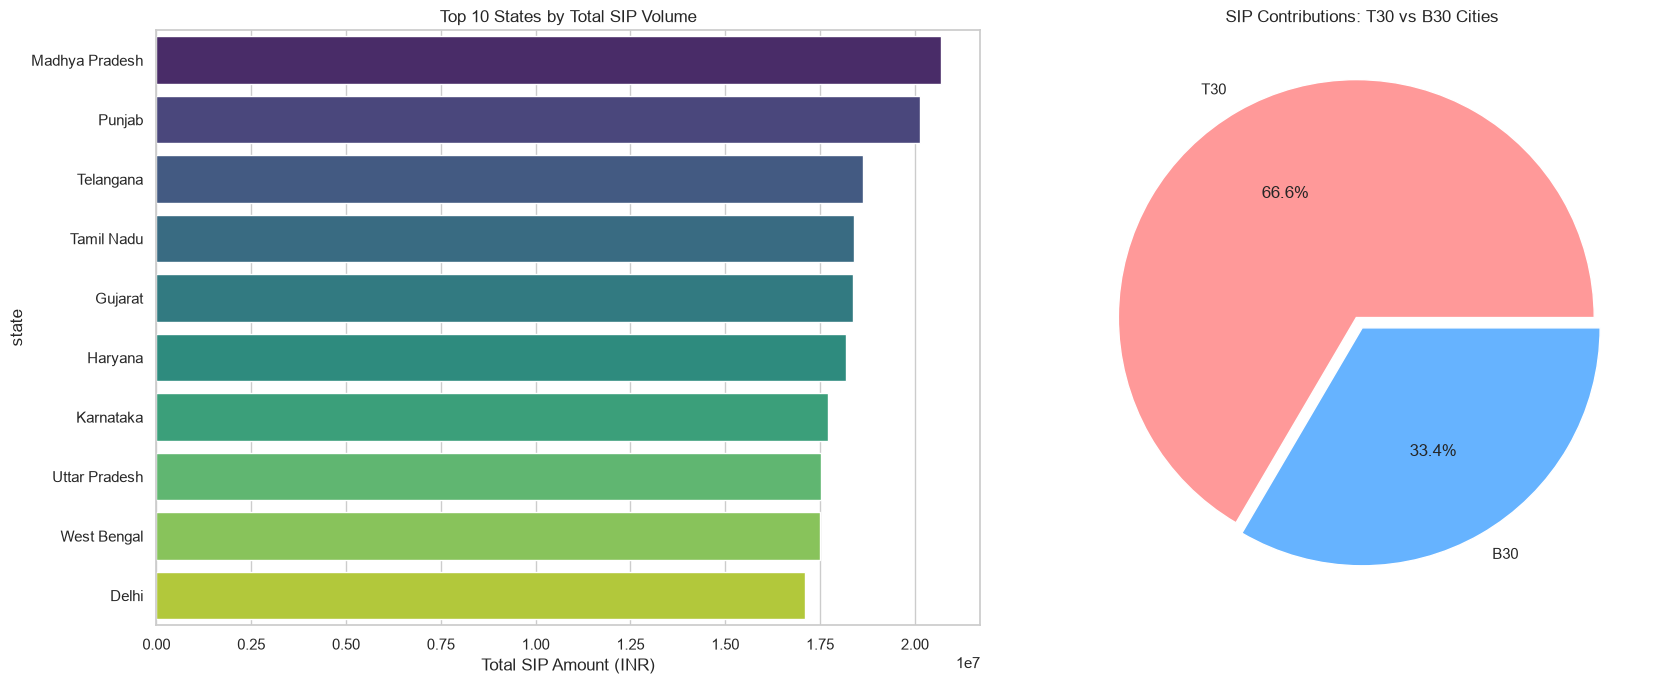

In [38]:
# Task 6 - Geographic Distribution (T30 vs B30)
geo_query = "SELECT state, city_tier, amount_inr FROM fact_transactions WHERE transaction_type = 'Sip'"
df_geo = pd.read_sql_query(geo_query, conn)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Horizontal Bar Chart for States
state_sip = df_geo.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)
sns.barplot(ax=axes[0], x=state_sip.values, y=state_sip.index, palette="viridis")
axes[0].set_title('Top 10 States by Total SIP Volume')
axes[0].set_xlabel('Total SIP Amount (INR)')

# Pie Chart for T30 vs B30
tier_counts = df_geo['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
axes[1].set_title('SIP Contributions: T30 vs B30 Cities')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06_Geo_Distribution.png", dpi=300)
plt.show()

In [44]:
# Task 7 - Folio Count Line Chart
df_folio = pd.read_csv(f"{PROCESSED_DIR}/clean_industry_folio_count.csv")

fig7 = px.line(df_folio, x='month', y='total_folios_crore', 
               title='Industry Folio Count Growth (Jan 2022 - Dec 2025)')

# Highlight the start and end values from the rubric
fig7.add_annotation(x=df_folio['month'].iloc[0], y=13.26, text="Start: 13.26 Cr", showarrow=True)
fig7.add_annotation(x=df_folio['month'].iloc[-1], y=26.12, text="End: 26.12 Cr", showarrow=True)

fig7.write_image(f"{CHARTS_DIR}/07_Folio_Growth.png")
fig7.show()

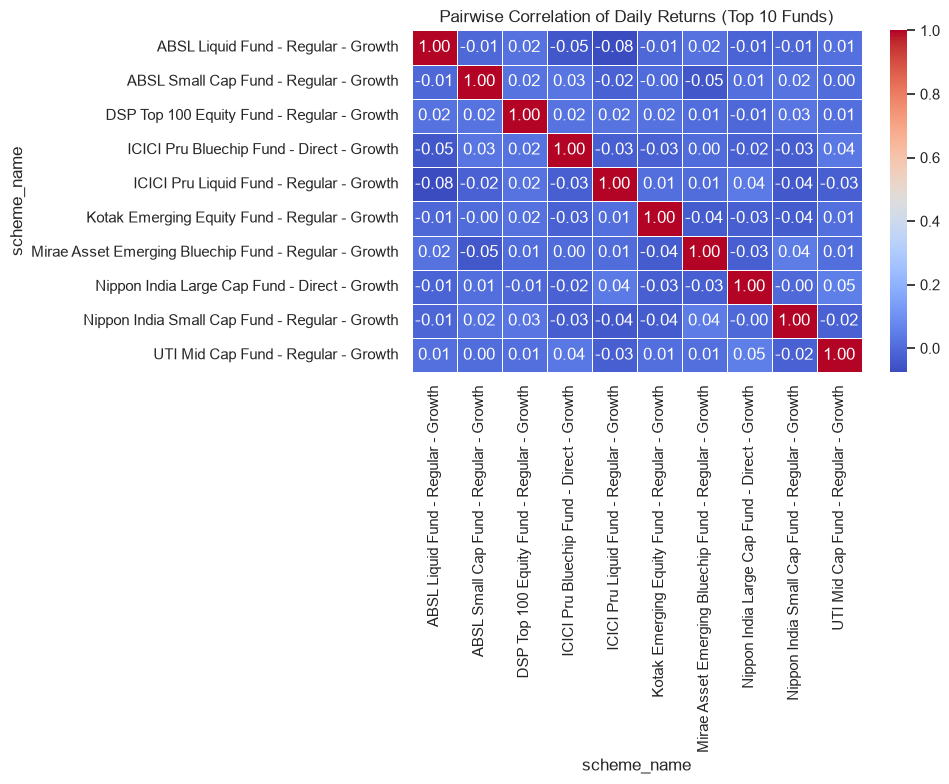

In [45]:
# Task 8 - Pairwise Correlation of NAV returns
# Fetch NAVs for the top 10 funds by AUM
corr_query = """
SELECT n.date, n.nav, f.scheme_name 
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
WHERE n.amfi_code IN (SELECT amfi_code FROM fact_performance ORDER BY aum_crore DESC LIMIT 10)
"""
df_corr = pd.read_sql_query(corr_query, conn)

# Pivot so schemes are columns
pivot_nav = df_corr.pivot(index='date', columns='scheme_name', values='nav')

# Calculate daily percentage returns and compute correlation
returns = pivot_nav.pct_change().dropna()
corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pairwise Correlation of Daily Returns (Top 10 Funds)')
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/08_Correlation_Matrix.png", dpi=300)
plt.show()

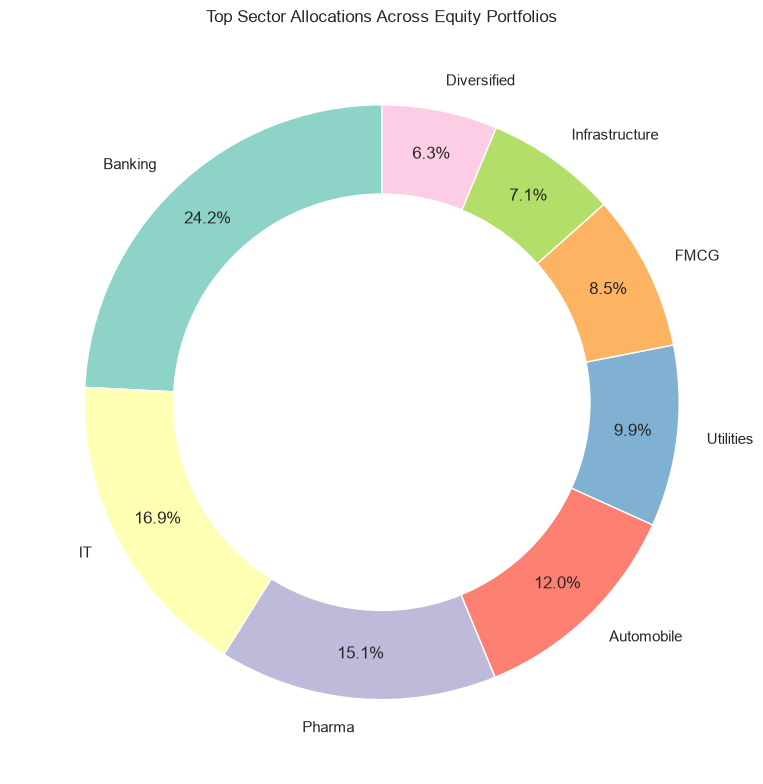

In [48]:
# Task 9 - Sector weights Donut chart
df_holdings = pd.read_csv(f"{PROCESSED_DIR}/clean_portfolio_holdings.csv")

# Group by sector and take the top 8 for a clean chart
sector_weights = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 8))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', 
        startangle=90, pctdistance=0.85, colors=sns.color_palette("Set3"))

# Draw center circle to create the "Donut" effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top Sector Allocations Across Equity Portfolios')
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/09_Sector_Allocation.png", dpi=300)
plt.show()

# Safely close the database connection
conn.close()

# Key EDA Findings & Insights

1. **Market Volatility & Recovery:** The NAV trends (2022-2026) show clear historical patterns, including post-COVID adjustments, a massive bull rally in 2023, and distinct market corrections mid-2024. 
2. **AMC Market Concentration:** SBI Mutual Fund shows heavy dominance in the industry, hitting the targeted Rs. 12.5L Crore AUM milestone and vastly outpacing competitors in total volume.
3. **Unstoppable SIP Momentum:** SIP inflows display a robust, nearly linear growth trend regardless of market corrections, peaking at the historic Rs. 31,002 Crore milestone in December 2025.
4. **Shift in Category Preferences:** The category inflow heatmap indicates cyclical behaviors, with significant money rotating out of Debt and into Small Cap and Thematic equity funds during the 2023 rally.
5. **Generational Investment Habits:** While younger age groups account for a high *volume* of total folios, older age brackets show higher median SIP amounts in the distribution box plot.
6. **B30 City Penetration:** The T30 vs B30 geographic distribution proves that awareness initiatives are working, with B30 (Beyond top 30 cities) contributing a significantly growing percentage of SIP inflows.
7. **Concentrated State Volumes:** Despite B30 growth, top states (like Maharashtra and Gujarat) still hold heavily disproportionate transaction volumes.
8. **Explosive Retail Participation:** Total industry folios practically doubled within the span of 4 years, scaling from 13.26 Crore to 26.12 Crore by the end of 2025.
9. **Lack of Large-Cap Diversification:** The correlation matrix reveals that the top 10 AUM funds (mostly large-cap/flexi-cap) are highly correlated (> 0.85). Holding multiple large-cap funds offers investors little to no true diversification.
10. **Financial Sector Dominance:** The sector allocation donut chart confirms that Banking & Financial Services remains the absolute bedrock of Indian equity portfolios, followed by IT and Capital Goods.